# 🚢 **Titanic Dataset - Exploratory Data Analysis (EDA)**

This notebook demonstrates:

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Conclusion



### 1) Primary  Objective
- The objective of this exploratory data analysis is to investigate, clean, and analyze the Titanic passenger data to uncover key factors, trends, and demographic patterns that influenced passenger survival.
- The main goal is to identify the most significant features that contributed to survival and provide insights that can be used for predictive modeling.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/competitions/titanic/data

- The data has been split into two groups:

  1-training set (train.csv)

  
  2-test set (test.csv)

- We will use the two datasets to perform our analysis and build predictive models.
- The training set contains the following columns:
- PassengerId
- Survived
- Pclass
- Name
- Sex
- Age
- SibSp
- Parch
- Ticket
- Fare
- Cabin
- Embarked
  
Our target variable is 'Survived', which indicates whether a passenger survived (1) or did not survive (0).

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib and Seaborn Library.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)



### Import the CSV data into the Pandas Dataframe

In [13]:
# we will use both train and test dataset for EDA as there are some features data that 
# is also in the test dataset which is not in the train dataset. So we will combine both datasets for EDA.

df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

# Combine datasets row-wise
df = pd.concat([df1, df2], ignore_index=True)

### Display the First five Rows

In [14]:
# Preview  of data set 
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [15]:
df2.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [16]:
df1.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [24]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# check the shape of data set
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


### 3. Key Feature Columns Summary

| Column Name | Category / Type | Description |
| :--- | :--- | :--- |
| **PassengerId** | Numerical | Unique ID per passenger |
| **Pclass** | Categorical | Ticket class (`1` = 1st, `2` = 2nd, `3` = 3rd) |
| **Name**, **Sex**, **Age** | Demographics | Passenger profile details |
| **SibSp** | Numerical | Number of siblings / spouses aboard |
| **Parch** | Numerical | Number of parents / children aboard |
| **Ticket**, **Fare**, **Cabin** | Logistics | Ticket ID, price paid, and cabin number |
| **Embarked** | Categorical | Port of Embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton) |

Survival is not in test dataset, so we will use train dataset for our analysis.

In [19]:
# DIfferentiate numerical and catagorical features
numerical_features=df.select_dtypes(exclude="object").columns.tolist()
catagorical_features=df.select_dtypes(include="object").columns.tolist()
print(f"Numerical features in the dataset are :{numerical_features}")
print(f"Catagorical  features in the dataset are :{catagorical_features}")

Numerical features in the dataset are :['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Catagorical  features in the dataset are :['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


### 3- Data cleaning and Preprocessing

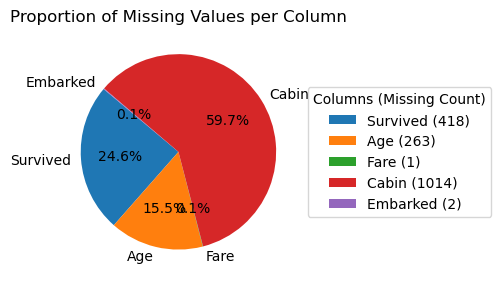

In [20]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

legend_labels = [f"{col} ({count})" for col, count in zip(missing_values.index, missing_values.values)]

# 3. Plot Pie Chart
plt.figure(figsize=(5,5))
ax = missing_values.plot(
    kind='pie',  
    autopct='%1.1f%%',
    startangle=140
)
# 
plt.title("Proportion of Missing Values per Column")
plt.ylabel("")

# Add legend with counts
plt.legend(legend_labels, title="Columns (Missing Count)", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

<!-- - we have seen that 418 values are to be predicted in the `survived`column of the test dataset. So we will use the train dataset for our analysis and build predictive models.
- The `Age` column hase 263 missing values, which we will impute with the median value of the `Age` column. 
- The `Cabin` column has 1014 missing values, where we will apply some feature engineering. 
- The `Embarked` column has 2 missing values, which we will impute with the mode value of the `Embarked` column. -->

In [21]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [22]:

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
209,210,1.0,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31.0000,A31,C
221,222,0.0,2,"Bracken, Mr. James H",male,27.0,0,0,220367,13.0000,NaN,S
622,623,1.0,3,"Nakid, Mr. Sahid",male,20.0,1,1,2653,15.7417,NaN,C
162,163,0.0,3,"Bengtsson, Mr. John Viktor",male,26.0,0,0,347068,7.7750,NaN,S
1156,1157,NaN,3,"Lyntakoff, Mr. Stanko",male,NaN,0,0,349235,7.8958,NaN,S


In [23]:
# first of all we will handle the missing values in the age column
# df["Age"].describe()
df["Age"] = df["Age"].fillna(df["Age"].median())
df[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


# Univariate Analysis


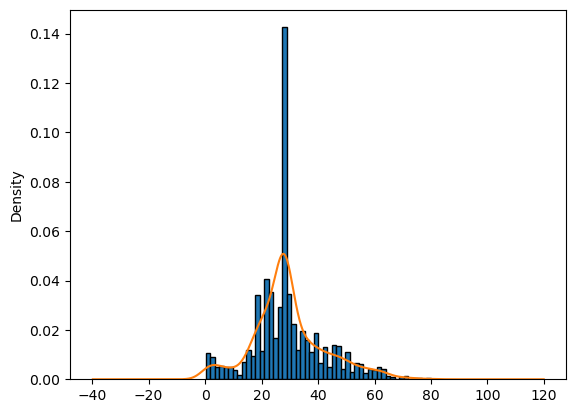

In [27]:
# First take a look at the age distribution of the passengers in the dataset.
#  We will use a histogram to visualize the distribution of ages.
ax = df["Age"].plot.hist(bins=50, density=True, edgecolor='black')
df["Age"].plot.kde(ax=ax)
plt.show()

Max age of the passengers is 80 years and the minimum age is 0.42 years. The average age of the passengers is 29.7 years.The age distribution tell us that the majority of the passengers are between 20 and 40 years old. The distribution is right-skewed, indicating that there are more younger passengers than older ones.

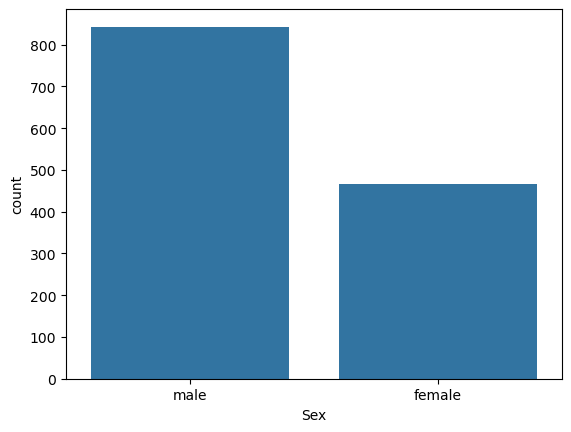

In [ ]:
# now we will check the sex distribution of the passengers in the dataset. 
# We will use a bar chart to visualize the distribution of sexes.
sns.countplot(x="Sex", data=df)
plt.show()


From the bar chart, we can see that the majority of the passengers are male, with a count of around 577, while the count of female passengers is around 314. This indicates that the Titanic had a higher proportion of male passengers compared

<Axes: xlabel='Fare', ylabel='Density'>

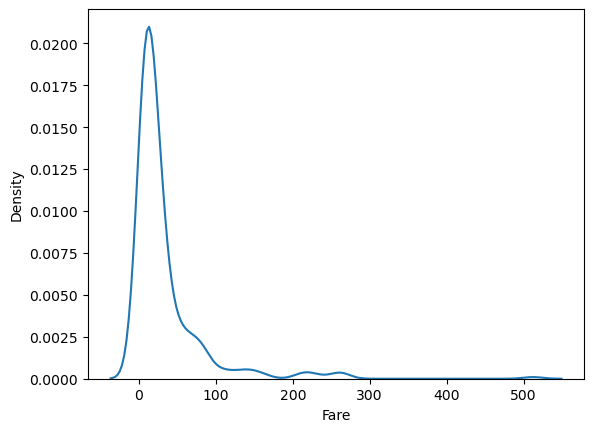

In [34]:
# now we will check the range of fares paid by the passengers in the dataset. 
# We will use a box plot to visualize the distribution of fares.    
sns.kdeplot(x="Fare", data=df)

From the kde plot , we can see that the majority of the passengers paid a fare between 0 and 100. The distribution is right-skewed, indicating that there are more passengers who paid lower fares than those who paid higher fares. There are also some outliers in the fare distribution, with a few passengers paying significantly higher fares than the rest.

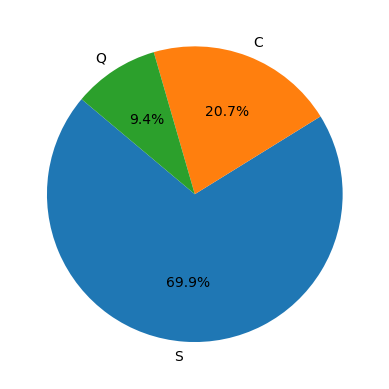

In [37]:
# Now lets look at the embarked column to see the distribution of 
# passengers based on their port of embarkation. We will use a bar
#  chart to visualize the distribution of embarked ports.
plt.pie(df["Embarked"].value_counts(), labels=df["Embarked"].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.show()

From the pie chart, we can see that the majority of the passengers embarked from Southampton (S), with a count of around 644, while the count of passengers who embarked from Cherbourg (C) is around 168 and from Queenstown (Q) is around 77. This indicates that the Titanic had a higher proportion of passengers who embarked from Southampton.

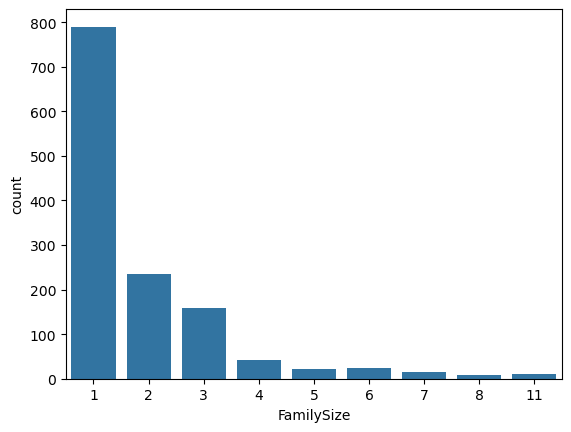

In [38]:
# Next we will analyze on the basis of family size. 
# We will create a new feature called "FamilySize" which is the sum of "SibSp" and "Parch" plus 1 (for the passenger themselves).
#  We will then visualize the distribution of family sizes using a bar chart.
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
sns.countplot(x="FamilySize", data=df)
plt.show()

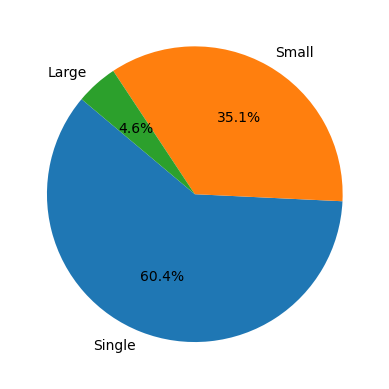

In [40]:
# we can make catagories of family size as follows:
# 1. Single (FamilySize = 1)
# 2. Small (FamilySize = 2-4)
# 3. Large (FamilySize >= 5)
df["FamilySizeCategory"] = pd.cut(df["FamilySize"], bins=[0, 1, 5,11], labels=["Single", "Small", "Large"])
# lets make a pie chart to visualize the distribution of family size categories.
plt.pie(df["FamilySizeCategory"].value_counts(), labels=df["FamilySizeCategory"].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.show()

From the pie chart, we can see that the mostly passengers are traveling alone (Single), with a percentage of around 60.4%, while the count of passengers traveling with small families (Small) is around 35.1% and with large families (Large) is around 4.6%. This indicates that the Titanic had a higher proportion of passengers traveling alone.

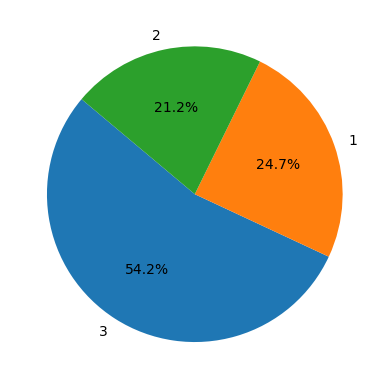

In [41]:
# Next we will check the distribution of passengers based on their passenger class (Pclass).
# We will use a pie chart to visualize the distribution of passenger classes.
plt.pie(df["Pclass"].value_counts(), labels=df["Pclass"].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.show()

From the pie chart ,we can see that majority were traveling in the 3rd class having less fare and less facilities, while the 1st class passengers were less in number but had more fare and more facilities. The 2nd class passengers were in between the 1st and 3rd class passengers in terms of fare and facilities.

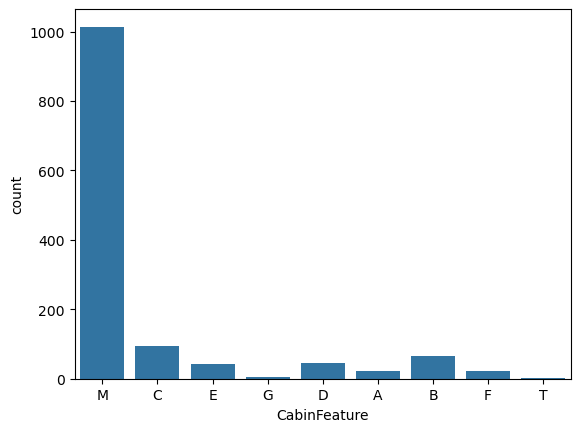

In [44]:
# next we have to analyze the cabin as there might be some information in the cabin column t
# that can be useful for our analysis.For more detail about the cabins you can fine from
#  this link: https://www.encyclopedia-titanica.org/cabins.html
df["Cabin"].fillna("Missing", inplace=True)
df["CabinFeature"] = df["Cabin"].str[0]
sns.countplot(x="CabinFeature", data=df)
plt.show()

We can see that the majority of the passengers were in the C cabin, followed by the B and D cabins. The A, E, F, and G cabins had fewer passengers. The "Missing" category represents passengers whose cabin information is not available. This distribution indicates that the Titanic had a higher proportion of passengers in the C cabin, which may have been more affordable or accessible for many passengers.

# Bivariate Analysis

<Axes: xlabel='Survived', ylabel='Count'>

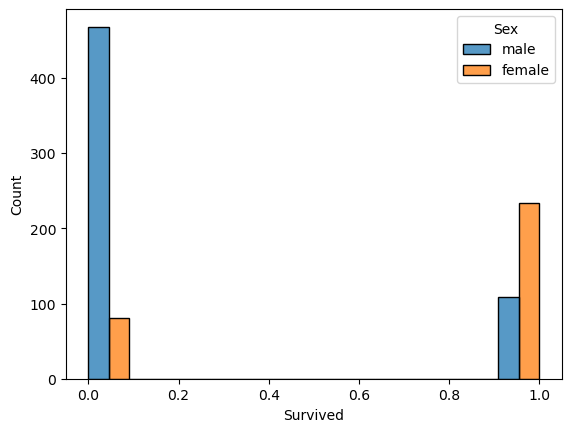

In [71]:
# now we will correlate the columns with survival and check their dependendy on each other
# First we will analyze the relation of sex with Survival
(pd.crosstab(df1['Sex'], df['Survived']))
sns.histplot(data=df1,x="Survived",hue="Sex",multiple="dodge")

From the Histogram,it can be analyzed that if you are a male then there are more chances that you will get died


In [72]:
# Moving further, we will analyze the survival dependency on the Age of the person
df1.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64